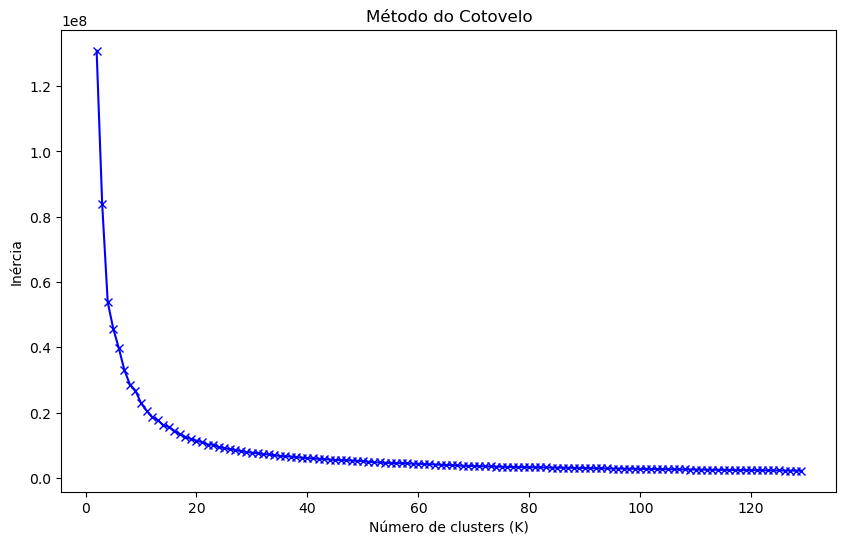

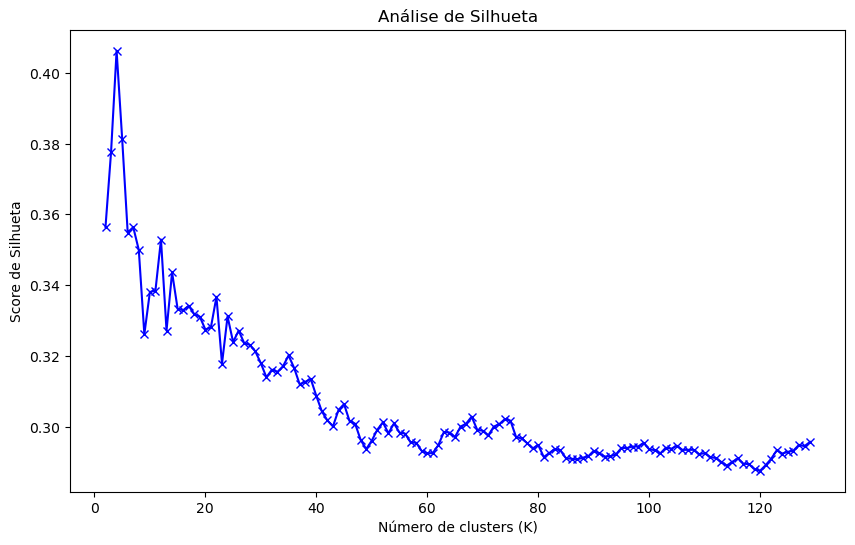

SVC(kernel='linear', probability=True, random_state=7)
{'without_cluster': {'recall': 0.08333333333333333, 'f1': 0.06191109085845927, 'auc': 0.7598296072038504}, 'with_cluster': {'recall': 0.10087719298245613, 'f1': 0.08403648008911166, 'auc': 0.7142314211043832}}
SVC(probability=True, random_state=7)
{'without_cluster': {'recall': 0.021929824561403508, 'f1': 0.004859563197824582, 'auc': 0.45827187807276304}, 'with_cluster': {'recall': 0.021929824561403508, 'f1': 0.0045986177565124926, 'auc': 0.45990852869637217}}
SVC(kernel='poly', probability=True, random_state=7)
{'without_cluster': {'recall': 0.03070175438596491, 'f1': 0.010214426526346031, 'auc': 0.4958307457434145}, 'with_cluster': {'recall': 0.03070175438596491, 'f1': 0.010601899696825057, 'auc': 0.49094343528437606}}
RandomForestClassifier(random_state=7)
{'without_cluster': {'recall': 0.12719298245614036, 'f1': 0.10050995544416597, 'auc': 0.7606770429022407}, 'with_cluster': {'recall': 0.13157894736842105, 'f1': 0.107372598162

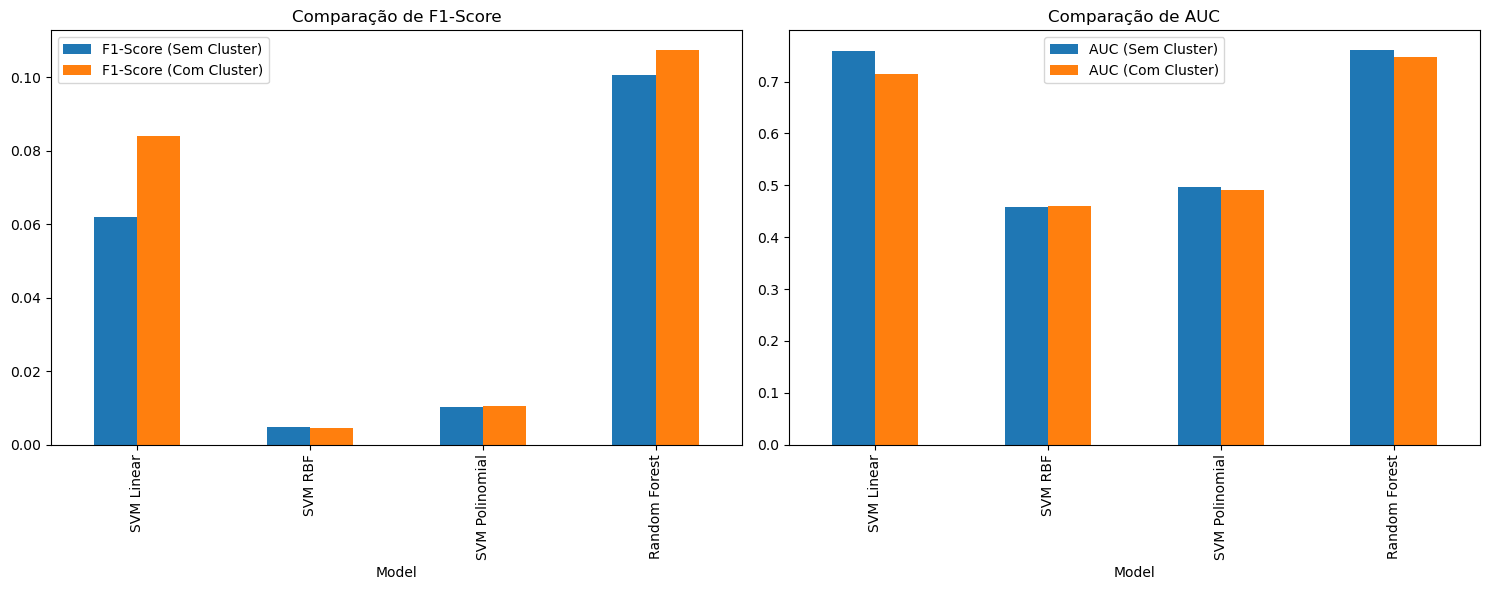

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, silhouette_score

# Carregar Dataset Spotify
df = pd.read_csv("dataset.csv", index_col=0).sample(frac=0.01, random_state=7)  # Amostragem de 1% dos dados para performance

# Drop Colunas irrelevantes
col_irrelevantes = ['track_id', 'track_name']
df = df.drop(columns=col_irrelevantes)

# Tratamento de features booleanas
df['explicit'] = df['explicit'].astype(int)

# Definindo as colunas numéricas e categóricas
col_numericas = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
                 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature', 'explicit']
col_categoricas = ['track_genre', 'artists', 'album_name']

# Pré-Processamento
kmeans_pre_processamento = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), col_numericas)
    ],
    remainder='drop'
)

X_scaled = kmeans_pre_processamento.fit_transform(df)
X_scaled = pd.DataFrame(X_scaled, columns=col_numericas)

for column in col_categoricas:
    encoder = LabelEncoder()
    X_scaled[column] = encoder.fit_transform(df[column])
    if column == 'track_genre':
        y = X_scaled[column] # Separando um target para Modelos de Classificação

# Data test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=7, shuffle=True, stratify=y)

# Aplicando KMeans para encontrar clusters encontrar o K ideal
k_range = [n for n in range(2, 130)]
inertias = []
silhouette_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=7)
    preds = kmeans.fit_predict(X_scaled, y)
    inertias.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, preds)
    silhouette_scores.append(score)

# Análise do Cotovelo
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bx-')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')
plt.show()

# Análise de silhueta
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, 'bx-')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Score de Silhueta')
plt.title('Análise de Silhueta')
plt.show()

# K ideal para KMeans fica no Elbow e com maior Silhouette Score
melhor_k = 12
kmeans = KMeans(n_clusters=melhor_k, random_state=7)
kmeans.fit(X_scaled)

# Adicionar distância ao centróide como nova feature
def get_cluster_distances(X, kmeans_model):
    distances = pd.DataFrame(np.min(kmeans_model.transform(X), axis=1), columns=['cluster_distance'], index=X.index)
    return distances

X_train_dist = get_cluster_distances(X_train, kmeans)
X_test_dist = get_cluster_distances(X_test, kmeans)

# Concatenar com features originais
X_train = X_train.drop(columns=['track_genre'])
X_test = X_test.drop(columns=['track_genre'])
X_train_with_dist = pd.concat([X_train, X_train_dist], axis=1)
X_test_with_dist = pd.concat([X_test, X_test_dist], axis=1)

# Treinar modelos com e sem a feature de cluster
models = {
    'SVM Linear': SVC(kernel='linear',probability=True, random_state=7),
    'SVM RBF': SVC(kernel='rbf',probability=True, random_state=7),
    'SVM Polinomial': SVC(kernel='poly',probability=True, random_state=7),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=7)
}

results = {}

for name, model in models.items():
    # Sem cluster feature
    print(model)
    modelo_treinado = model.fit(X_train, y_train)
    y_pred = modelo_treinado.predict(X_test)
    y_prob = modelo_treinado.predict_proba(X_test)
        
    results[name] = {
        'without_cluster': {
            #'precision': precision_score(y_test, y_pred, average='weighted'),
            'recall': recall_score(y_test, y_pred, average='weighted'),
            'f1': f1_score(y_test, y_pred, average='weighted'),
            'auc': roc_auc_score(y_test, y_prob, average='weighted', multi_class='ovo')
        }
    }
    # Com cluster feature
    modelo_treinado = model.fit(X_train_with_dist, y_train)
    y_pred = modelo_treinado.predict(X_test_with_dist)
    y_prob = modelo_treinado.predict_proba(X_test_with_dist)
    
    results[name]['with_cluster'] = {
        #'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall': recall_score(y_test, y_pred, average='weighted'),
        'f1': f1_score(y_test, y_pred, average='weighted'),
        'auc': roc_auc_score(y_test, y_prob, average='weighted', multi_class='ovo')
    }
    print(results[name])

# Comparar resultados
comparison = []
for model_name, res in results.items():
    comparison.append({
        'Model': model_name,
        'F1-Score (Sem Cluster)': res['without_cluster']['f1'],
        'F1-Score (Com Cluster)': res['with_cluster']['f1'],
        'AUC (Sem Cluster)': res['without_cluster']['auc'],
        'AUC (Com Cluster)': res['with_cluster']['auc']
    })
    print(f"{model_name} - F1-Score Sem Cluster: {res['without_cluster']['f1']:.4f}, Com Cluster: {res['with_cluster']['f1']:.4f}")

df_comparison = pd.DataFrame(comparison)
print(df_comparison)

# Plotar comparação dos modelos
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
df_comparison.plot(x='Model', y=['F1-Score (Sem Cluster)', 'F1-Score (Com Cluster)'], 
                   kind='bar', ax=axes[0], title='Comparação de F1-Score')
df_comparison.plot(x='Model', y=['AUC (Sem Cluster)', 'AUC (Com Cluster)'], 
                   kind='bar', ax=axes[1], title='Comparação de AUC')
plt.tight_layout()
plt.show()